In [16]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time
import math

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

In [17]:
def ponto_fixo(g, x0, tol, max_iter=100):
    """
    Método da Iteração de Ponto Fixo.

    Parâmetros:
    g: Função de iteração g(x) tal que x = g(x)
    x0: Chute inicial
    tol: Tolerância para o erro (critério de parada)
    max_iter: Número máximo de iterações

    Retorna:
    raiz: Aproximação da raiz
    iteracoes: Número de iterações realizadas
    erro: Erro estimado na última iteração
    historico: Lista com os valores de x a cada iteração
    """
    x_atual = x0
    iteracoes = 0
    erro = float('inf')
    historico = [x_atual]

    print(f"{'Iter':<5} {'x':<15} {'Erro (%)':<15}")

    while iteracoes < max_iter:
        x_novo = g(x_atual)
        iteracoes += 1

        if x_novo != 0:
            erro = np.abs((x_novo - x_atual) / x_novo) * 100

        historico.append(x_novo)

        print(f"{iteracoes:<5} {x_novo:<15.8f} {erro:<15.6f}")

        if erro <= tol:
            break

        x_atual = x_novo

    return x_novo, iteracoes, erro, historico

In [18]:
# Definição da função g(x)
def g2(x):
    return 2 * np.sin(np.sqrt(x))

# Parâmetros
x0 = 0.5
tolerancia = 0.001 # 0.001%

print("Questão 2:")
raiz, it, erro, hist = ponto_fixo(g2, x0, tolerancia)

print(f"\nRaiz aproximada: {raiz:.8f} encontrada em {it} iterações.")

Questão 2:
Iter  x               Erro (%)       
1     1.29927388      61.516967      
2     1.81714750      28.499262      
3     1.95057392      6.840367       
4     1.96974251      0.973152       
5     1.97206888      0.117966       
6     1.97234418      0.013958       
7     1.97237666      0.001647       
8     1.97238049      0.000194       

Raiz aproximada: 1.97238049 encontrada em 8 iterações.


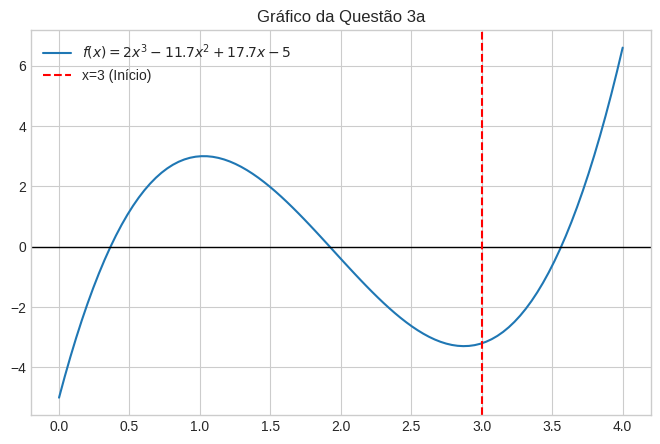

Questão 3b: Bisseção

Iter  a          b          x_ns       f(x_ns)   
1     3.0000     4.0000     3.5000     -0.6250   
2     3.5000     4.0000     3.7500     2.3125    
3     3.5000     3.7500     3.6250     0.6867    
4     3.5000     3.6250     3.5625     -0.0069   
5     3.5625     3.6250     3.5938     0.3303    
Questão 3c: Ponto Fixo
Iter  x               Erro (%)       
1     3.18079096      5.683837       
2     3.33395917      4.594184       
3     3.44254325      3.154182       
4     3.50632999      1.819188       
5     3.53829371      0.903366       


In [19]:
# Definição da função f(x)
def f3(x):
    return 2*x**3 - 11.7*x**2 + 17.7*x - 5

# ITEM A: Graficamente
x_vals = np.linspace(0, 4, 100)
y_vals = f3(x_vals)

plt.figure(figsize=(8, 5))
plt.plot(x_vals, y_vals, label='$f(x) = 2x^3 - 11.7x^2 + 17.7x - 5$')
plt.axhline(0, color='black', linewidth=1) # Eixo X
plt.axvline(3, color='r', linestyle='--', label='x=3 (Início)')
plt.title('Gráfico da Questão 3a')
plt.legend()
plt.show()

# Pela visualização, a maior raiz está entre 3 e 4.

# ITEM B: Bisseção (5 iterações)
def bissecao_manual(f, a, b, num_iter):
    print(f"\n{'Iter':<5} {'a':<10} {'b':<10} {'x_ns':<10} {'f(x_ns)':<10}")
    for i in range(num_iter):
        x_ns = (a + b) / 2
        sinal = f(a) * f(x_ns)
        print(f"{i+1:<5} {a:<10.4f} {b:<10.4f} {x_ns:<10.4f} {f(x_ns):<10.4f}")

        if sinal < 0:
            b = x_ns
        elif sinal > 0:
            a = x_ns
        else:
            break
    return x_ns

print("Questão 3b: Bisseção")
# Intervalo escolhido visualmente [3, 4] pois f(3) < 0 e f(4) > 0
raiz_bissecao = bissecao_manual(f3, 3, 4, 5)

# TEM C: Ponto Fixo (5 iterações)
print("Questão 3c: Ponto Fixo")
# Precisa manipular a função para x = g(x).
# Tentativa isolando o termo x: 17.7x = -2x^3 + 11.7x^2 + 5
def g3(x):
    return (-2*x**3 + 11.7*x**2 + 5) / 17.7

raiz_pf, _, _, _ = ponto_fixo(g3, x0=3, tol=1e-10, max_iter=5)

In [20]:
def ponto_fixo_runner(g, x0, tol, max_iter=200):
    start_time = time.time()
    try:
        x_atual = x0
        for i in range(max_iter):
            x_novo = g(x_atual)
            if np.isnan(x_novo) or np.isinf(x_novo): # Checa divergência explosiva
                return x_atual, i+1, False, (time.time() - start_time)

            if x_novo != 0:
                erro = np.abs((x_novo - x_atual) / x_novo)
            else:
                erro = abs(x_novo - x_atual)

            if erro < tol:
                return x_novo, i+1, True, (time.time() - start_time)

            x_atual = x_novo

        return x_novo, max_iter, False, (time.time() - start_time)
    except:
        return x0, 0, False, (time.time() - start_time)

# Lista de Funções com tentativas de g(x) para o Ponto Fixo
funcoes = [
    {
        "nome": "f1: 2x^4... [-15]",
        "f": lambda x: 2*x**4 + 4*x**3 + 3*x**2 - 10*x - 15,
        "g": lambda x: (2*x**4 + 4*x**3 + 3*x**2 - 15) / 10,
        "intervalo": [0, 3],
        "x0": 1.5 # Chute inicial (meio do intervalo)
    },
    {
        "nome": "f2: (x+3)...",
        "f": lambda x: (x+3)*(x+1)*(x-2)**3,
        # Tentativa genérica x = x - f(x)/k
        "g": lambda x: x - ((x+3)*(x+1)*(x-2)**3)/100,
        "intervalo": [0, 5],
        "x0": 2.5
    },
    {
        "nome": "f3: 5x^3...",
        "f": lambda x: 5*x**3 + x**2 - np.exp(1-2*x) + np.cos(x) + 20,
        # Isolando x do x^3: x = cbrt()
        "g": lambda x: np.cbrt((-x**2 + np.exp(1-2*x) - np.cos(x) - 20)/5),
        "intervalo": [-5, 5],
        "x0": 0
    },
    {
        "nome": "f4: sin(x)x + 4",
        "f": lambda x: np.sin(x)*x + 4,
        # Isolando x: x = -4/sin(x)
        "g": lambda x: -4/np.sin(x) if np.sin(x) != 0 else x,
        "intervalo": [1, 5],
        "x0": 4
    },
    {
        "nome": "f5: (x-3)^5 * ln(x)",
        "f": lambda x: ((x-3)**5) * np.log(x),
        # Isolando x do log: x = e^(f(x)/(x-3)^5)... complexo, tentando x + f(x) pequeno
        "g": lambda x: x - (((x-3)**5) * np.log(x))/10,
        "intervalo": [2, 5],
        "x0": 4
    },
    {
        "nome": "f6: x^10 - 1",
        "f": lambda x: x**10 - 1,
        # Isolando x: x = 1^(1/10) é trivialmente 1, vamos tentar x = (1/x^9)
        "g": lambda x: 1/(x**9) if x!=0 else x,
        "intervalo": [0.8, 1.2],
        "x0": 1.1
    }
]

resultados = []

for item in funcoes:
    f = item["f"]
    g = item["g"]
    a, b = item["intervalo"]
    x0 = item["x0"]
    tol = 1e-10

    # Bisseção
    r_bis, it_bis, conv_bis, t_bis = bissecao_runner(f, a, b, tol)
    resultados.append([item["nome"], "Bisseção", r_bis, it_bis, conv_bis, t_bis])

    # Falsa Posição
    r_fp, it_fp, conv_fp, t_fp = falsa_posicao(f, a, b, tol)
    resultados.append([item["nome"], "Falsa Posição", r_fp, it_fp, conv_fp, t_fp])

    # Ponto Fixo (NOVO)
    r_pf, it_pf, conv_pf, t_pf = ponto_fixo_runner(g, x0, tol)
    resultados.append([item["nome"], "Ponto Fixo", r_pf, it_pf, conv_pf, t_pf])

# Tabela Final
df = pd.DataFrame(resultados, columns=["Função", "Método", "Raiz Encontrada", "Iterações", "Convergiu?", "Tempo (s)"])
pd.set_option('display.float_format', lambda x: '%.8f' % x)
display(df)

,Função,Método,Raiz Encontrada,Iterações,Convergiu?,Tempo (s)
0,f1: 2x^4... [-15],Bisseção,1.49287871,35,True,0.00008869
1,f1: 2x^4... [-15],Falsa Posição,1.49287871,78,True,0.00053215
2,f1: 2x^4... [-15],Ponto Fixo,1.50000000,0,False,0.00010324
3,f2: (x+3)...,Bisseção,2.00012207,13,True,0.00002956
4,f2: (x+3)...,Falsa Posição,1.71440914,200,False,0.00068331
5,f2: (x+3)...,Ponto Fixo,2.11870631,200,False,0.00130558
6,f3: 5x^3...,Bisseção,-0.92956046,37,True,0.00060153
7,f3: 5x^3...,Falsa Posição,1.56876926,200,False,0.00493598
8,f3: 5x^3...,Ponto Fixo,2.26827026,200,False,0.00152683
9,f4: sin(x)x + 4,Bisseção,4.32323954,34,True,0.00014234
